In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import ttest_ind, chi2_contingency


In [78]:
# load parquet file
cup = pd.read_parquet(r"C:\Users\thelilturks\Documents\data project\cup_series.parquet")

In [79]:
#check columns and data types
cup.info()

<class 'pandas.DataFrame'>
RangeIndex: 101157 entries, 0 to 101156
Data columns (total 21 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Season   101157 non-null  int32  
 1   Race     101157 non-null  int32  
 2   Track    101157 non-null  str    
 3   Name     101157 non-null  str    
 4   Length   101005 non-null  float64
 5   Surface  101005 non-null  str    
 6   Finish   101157 non-null  int32  
 7   Start    98078 non-null   float64
 8   Car      101157 non-null  str    
 9   Driver   101157 non-null  str    
 10  Make     101157 non-null  str    
 11  Pts      90961 non-null   float64
 12  Laps     98918 non-null   float64
 13  Led      101156 non-null  float64
 14  Status   101157 non-null  str    
 15  Team     101157 non-null  str    
 16  S1       3510 non-null    float64
 17  S2       3510 non-null    float64
 18  S3       0 non-null       float64
 19  Rating   31863 non-null   float64
 20  Win      101157 non-null  float64
dty

In [80]:
#get a sense of what the data looks like
cup.head()

,Season,Race,Track,Name,Length,Surface,Finish,Start,Car,Driver,...,Pts,Laps,Led,Status,Team,S1,S2,S3,Rating,Win
0,1949,1,Charlotte Speedway,150 Miles at Charlotte Speedway,0.75,dirt,1,12.0,34,Jim Roper,...,NaN,197.0,47.0,running,R.B. McIntosh (Owner),NaN,NaN,NaN,NaN,1.0
1,1949,1,Charlotte Speedway,150 Miles at Charlotte Speedway,0.75,dirt,2,5.0,47,Fonty Flock,...,NaN,NaN,0.0,running,Grady Cole (Owner),NaN,NaN,NaN,NaN,0.0
2,1949,1,Charlotte Speedway,150 Miles at Charlotte Speedway,0.75,dirt,3,3.0,22,Red Byron,...,NaN,NaN,0.0,running,Raymond Parks (Owner),NaN,NaN,NaN,NaN,0.0
3,1949,1,Charlotte Speedway,150 Miles at Charlotte Speedway,0.75,dirt,4,14.0,2,Sam Rice,...,NaN,NaN,0.0,running,Rice Racing,NaN,NaN,NaN,NaN,0.0
4,1949,1,Charlotte Speedway,150 Miles at Charlotte Speedway,0.75,dirt,5,2.0,90,Tim Flock,...,NaN,NaN,0.0,running,Buddy Elliott (Owner),NaN,NaN,NaN,NaN,0.0


In [81]:
#check how recent the data goes
cup.tail(10)

,Season,Race,Track,Name,Length,Surface,Finish,Start,Car,Driver,...,Pts,Laps,Led,Status,Team,S1,S2,S3,Rating,Win
101147,2026,27,Darlington Raceway,Cook Out Southern 500,1.366,paved,29,9.0,3,Austin Dillon,...,8.0,366.0,0.0,running,Richard Childress Racing,NaN,NaN,NaN,38.2,0.0
101148,2026,27,Darlington Raceway,Cook Out Southern 500,1.366,paved,30,15.0,35,Riley Herbst,...,7.0,366.0,0.0,running,23XI Racing,NaN,NaN,NaN,54.6,0.0
101149,2026,27,Darlington Raceway,Cook Out Southern 500,1.366,paved,31,27.0,10,Ty Dillon,...,6.0,366.0,0.0,running,Kaulig Racing,NaN,NaN,NaN,33.2,0.0
101150,2026,27,Darlington Raceway,Cook Out Southern 500,1.366,paved,32,29.0,4,Noah Gragson,...,5.0,366.0,0.0,running,Front Row Motorsports,NaN,NaN,NaN,37.3,0.0
101151,2026,27,Darlington Raceway,Cook Out Southern 500,1.366,paved,33,16.0,41,Cole Custer,...,4.0,366.0,0.0,running,Haas Factory Team,NaN,NaN,NaN,40.3,0.0
101152,2026,27,Darlington Raceway,Cook Out Southern 500,1.366,paved,34,31.0,88,Connor Zilisch,...,3.0,365.0,0.0,running,Trackhouse Racing,NaN,NaN,NaN,32.5,0.0
101153,2026,27,Darlington Raceway,Cook Out Southern 500,1.366,paved,35,8.0,47,Ricky Stenhouse Jr.,...,2.0,363.0,0.0,running,Hyak Motorsports,NaN,NaN,NaN,35.2,0.0
101154,2026,27,Darlington Raceway,Cook Out Southern 500,1.366,paved,36,37.0,51,Cody Ware,...,1.0,363.0,0.0,running,Rick Ware Racing,NaN,NaN,NaN,26.5,0.0
101155,2026,27,Darlington Raceway,Cook Out Southern 500,1.366,paved,37,20.0,24,William Byron,...,6.0,319.0,0.0,engine,Hendrick Motorsports,9.0,8.0,NaN,83.8,0.0
101156,2026,27,Darlington Raceway,Cook Out Southern 500,1.366,paved,38,38.0,66,Chad Finchum,...,0.0,243.0,0.0,suspension,Garage 66,NaN,NaN,NaN,23.2,0.0


In [82]:
#check how a full season looks like
cup_2026 = cup[cup["Season"] == 2026]

print(cup_2026)

        Season  Race                           Track                   Name  \
100138    2026     1  Daytona International Speedway            DAYTONA 500   
100139    2026     1  Daytona International Speedway            DAYTONA 500   
100140    2026     1  Daytona International Speedway            DAYTONA 500   
100141    2026     1  Daytona International Speedway            DAYTONA 500   
100142    2026     1  Daytona International Speedway            DAYTONA 500   
...        ...   ...                             ...                    ...   
101152    2026    27              Darlington Raceway  Cook Out Southern 500   
101153    2026    27              Darlington Raceway  Cook Out Southern 500   
101154    2026    27              Darlington Raceway  Cook Out Southern 500   
101155    2026    27              Darlington Raceway  Cook Out Southern 500   
101156    2026    27              Darlington Raceway  Cook Out Southern 500   

        Length Surface  Finish  Start Car          

In [83]:
#generation of car in use
def assign_generation(season):
    if 1949 <= season <= 1966:
        return "Generation 1"
    elif 1967 <= season <= 1980:
        return "Generation 2"
    elif 1981 <= season <= 1991:
        return "Generation 3"
    elif 1992 <= season <= 2006:
        return "Generation 4"
    elif 2007 <= season <= 2012:
        return "Generation 5"
    elif 2013 <= season <= 2021:
        return "Generation 6"
    elif season >= 2022:
        return "Generation 7 / Next Gen"
    else:
        return "Unknown"

cup["Car_Generation"] = cup["Season"].apply(assign_generation)

In [84]:
#amount of entries per car generation
car_generation_races = cup.groupby("Car_Generation").size().reset_index(name="Entry_Count")
car_generation_races

,Car_Generation,Entry_Count
0,Generation 1,21743
1,Generation 2,17580
2,Generation 3,12052
3,Generation 4,21039
4,Generation 5,9288
5,Generation 6,13069
6,Generation 7 / Next Gen,6386


In [85]:
# make a copy of the dataframe for Joey Logano alone
logano = cup[cup["Driver"] == "Joey Logano"].copy()

# Create variables to use in tests and visualizations
logano["Year_Type"] = np.where(logano["Season"] % 2 == 0, "Even", "Odd")
logano["DNF"] = (
    logano["Status"].str.strip().str.lower() != "running"
).astype(int)
logano["Position_Gain"] = logano["Start"] - logano["Finish"]


logano.info()

<class 'pandas.DataFrame'>
Index: 642 entries, 75111 to 101127
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Season          642 non-null    int32  
 1   Race            642 non-null    int32  
 2   Track           642 non-null    str    
 3   Name            642 non-null    str    
 4   Length          638 non-null    float64
 5   Surface         638 non-null    str    
 6   Finish          642 non-null    int32  
 7   Start           642 non-null    float64
 8   Car             642 non-null    str    
 9   Driver          642 non-null    str    
 10  Make            642 non-null    str    
 11  Pts             642 non-null    float64
 12  Laps            642 non-null    float64
 13  Led             642 non-null    float64
 14  Status          642 non-null    str    
 15  Team            642 non-null    str    
 16  S1              199 non-null    float64
 17  S2              183 non-null    float64
 18 

In [86]:
# drop the S3 column as it is empty and not needed for analysis
cup = cup.drop(columns=["S3"])
cup.info()


<class 'pandas.DataFrame'>
RangeIndex: 101157 entries, 0 to 101156
Data columns (total 21 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Season          101157 non-null  int32  
 1   Race            101157 non-null  int32  
 2   Track           101157 non-null  str    
 3   Name            101157 non-null  str    
 4   Length          101005 non-null  float64
 5   Surface         101005 non-null  str    
 6   Finish          101157 non-null  int32  
 7   Start           98078 non-null   float64
 8   Car             101157 non-null  str    
 9   Driver          101157 non-null  str    
 10  Make            101157 non-null  str    
 11  Pts             90961 non-null   float64
 12  Laps            98918 non-null   float64
 13  Led             101156 non-null  float64
 14  Status          101157 non-null  str    
 15  Team            101157 non-null  str    
 16  S1              3510 non-null    float64
 17  S2              3510 

# There is nothing in S3, as it is the stage where you finish, so all the data is in Finish.

In [87]:
# info on Joey Logano's data
logano.info()

<class 'pandas.DataFrame'>
Index: 642 entries, 75111 to 101127
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Season          642 non-null    int32  
 1   Race            642 non-null    int32  
 2   Track           642 non-null    str    
 3   Name            642 non-null    str    
 4   Length          638 non-null    float64
 5   Surface         638 non-null    str    
 6   Finish          642 non-null    int32  
 7   Start           642 non-null    float64
 8   Car             642 non-null    str    
 9   Driver          642 non-null    str    
 10  Make            642 non-null    str    
 11  Pts             642 non-null    float64
 12  Laps            642 non-null    float64
 13  Led             642 non-null    float64
 14  Status          642 non-null    str    
 15  Team            642 non-null    str    
 16  S1              199 non-null    float64
 17  S2              183 non-null    float64
 18 

In [88]:
#number of races Joey Logano has participated in per year
print(logano["Season"].min())
print(logano["Season"].max())
print(logano["Season"].value_counts().sort_index())

2008
2026
Season
2008     3
2009    36
2010    36
2011    36
2012    36
2013    36
2014    36
2015    36
2016    36
2017    36
2018    36
2019    36
2020    36
2021    36
2022    36
2023    36
2024    36
2025    36
2026    27
Name: count, dtype: int64


In [89]:
# Logano DNF status
logano["Status"].value_counts()

Status
running       582
accident       46
engine          8
DVP             4
front hub       1
suspension      1
Name: count, dtype: int64

In [90]:
#Create a variable to indicate whether Joey Logano did not finish (DNF) a race
logano["DNF"] = (logano["Status"] != "running").astype(int)

<Axes: xlabel='Season'>

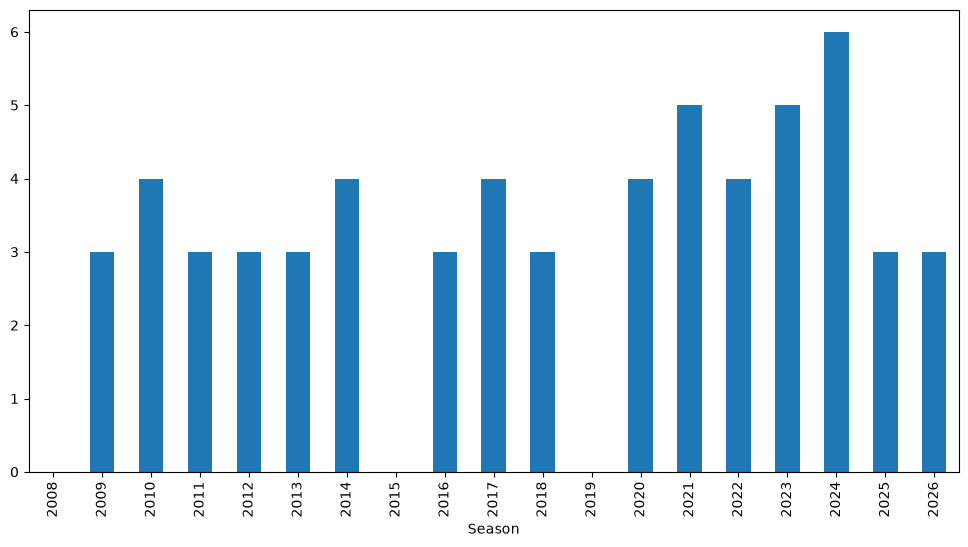

In [91]:
#visualize the number of DNFs per season for Joey Logano
dnfs_by_season = logano.groupby("Season")["DNF"].sum()
dnfs_by_season.plot(kind="bar", figsize=(12, 6))

In [92]:
# compare amount of races to amount of DNFs per season
logano.groupby("Season").agg(
    races=("DNF", "size"),
    dnfs=("DNF", "sum")
)

,races,dnfs
Season,,
2008,3,0
2009,36,3
2010,36,4
2011,36,3
2012,36,3
2013,36,3
2014,36,4
2015,36,0
2016,36,3


In [93]:
#compare amount of dnfs in even year and odd year seasons
dnf_comparison = (
    logano.groupby("Year_Type")
    .agg(
        races=("DNF", "size"),
        total_dnfs=("DNF", "sum"),
        dnf_rate=("DNF", "mean")
    )
    .reset_index()
)

dnf_comparison["dnf_rate"] = dnf_comparison["dnf_rate"] * 100

print(dnf_comparison)

  Year_Type  races  total_dnfs   dnf_rate
0      Even    318          34  10.691824
1       Odd    324          26   8.024691


In [94]:
# check to see if there is a significant difference in DNF rates between even and odd years using a chi-square test
table = pd.crosstab(logano["Year_Type"], logano["DNF"])
chi2, p_value, dof, expected = chi2_contingency(table)

print("p-value:", p_value)
if p_value < 0.05:
    print("There is a significant difference in DNF rates between even and odd years.")
else: 
    print("There is not a significant difference in DNF rates between even and odd years.")

p-value: 0.3052626919707164
There is not a significant difference in DNF rates between even and odd years.


# Although he has more DNFS in even years than odd years while having raced less in even years currently, there is not a significant difference in DNF rates between even and odd years.

In [95]:
# check the surface types Joey Logano has raced on and how many races he has
logano["Surface"].value_counts(dropna=False)

Surface
paved    576
road      59
NaN        4
dirt       3
Name: count, dtype: int64

In [96]:
#check which tracks that were NaN for surface type
logano.loc[
    logano["Surface"].isna(),
    ["Season", "Race", "Track", "Finish", "Status"]
]

,Season,Race,Track,Finish,Status
100196,2026,2,EchoPark Speedway,18,running
100760,2026,17,Naval Base Coronado,18,running
100829,2026,19,Chicagoland Speedway,12,running
100894,2026,21,North Wilkesboro Speedway,1,running


In [97]:
# fix the missing surface types for the tracks that were NaN
surface_updates = {
    "EchoPark Speedway": "paved",
    "Naval Base Coronado": "road",
    "Chicagoland Speedway": "paved",
    "North Wilkesboro Speedway": "paved"
}

cup["Surface"] = cup["Surface"].fillna(
    cup["Track"].map(surface_updates)
)

In [98]:
#update the logano dataframe after fixing the missing surface types
logano = cup[cup["Driver"] == "Joey Logano"].copy()

# Create analysis variables before using them in summaries or tests.
logano["Year_Type"] = np.where(logano["Season"] % 2 == 0, "Even", "Odd")
logano["DNF"] = (
    logano["Status"].str.strip().str.lower() != "running"
).astype(int)
logano["Position_Gain"] = logano["Start"] - logano["Finish"]


In [99]:
print(logano["Surface"].value_counts(dropna=False))


Surface
paved    579
road      60
dirt       3
Name: count, dtype: int64


In [100]:
#check Logano stats based on the length of a lap
length_summary = (
    logano.groupby("Length")
    .agg(
        races=("Finish", "size"),
        average_finish=("Finish", "mean"),
        win_rate=("Win", "mean"),
        average_rating=("Rating", "mean")
    )
    .reset_index()
)

print(length_summary.sort_values("Length"))

    Length  races  average_finish  win_rate  average_rating
0    0.526     35       10.371429  0.028571       97.488571
1    0.533     35       16.057143  0.085714       86.631429
2    0.750     33        9.575758  0.090909       96.875758
3    0.875      3        9.666667  0.000000       92.033333
4    1.000     64       13.875000  0.062500       90.223438
5    1.058     28       14.392857  0.071429       86.714286
6    1.250      4        3.500000  0.250000      107.450000
7    1.333      6        9.500000  0.166667       89.483333
8    1.366     26       14.153846  0.038462       89.100000
9    1.500    157       13.732484  0.070064       89.558599
10   1.540     25       16.240000  0.080000       89.072000
11   1.990     15       13.866667  0.000000       79.600000
12   2.000     46       12.847826  0.065217       93.923913
13   2.140      1        8.000000  0.000000       88.500000
14   2.200      2       17.000000  0.000000       63.600000
15   2.280      8       10.000000  0.000

In [101]:
# Check Logano's performance on 1.250 mile tracks which is his best track length based on the previous summary
logano.loc[
    logano["Length"] == 1.250,
    ["Track", "Season", "Finish", "Win"]
]

,Track,Season,Finish,Win
95289,World Wide Technology Raceway at Gateway,2022,1,1.0
96611,World Wide Technology Raceway at Gateway,2023,3,0.0
97942,World Wide Technology Raceway at Gateway,2024,5,0.0
99804,World Wide Technology Raceway at Gateway,2025,5,0.0


In [102]:
#add track name to the summary to see how Logano performs on each track
track_summary = (
    logano.groupby(["Track", "Length"])
    .agg(
        races=("Finish", "size"),
        average_finish=("Finish", "mean"),
        wins=("Win", "sum"),
        win_rate=("Win", "mean"),
        average_rating=("Rating", "mean")
    )
    .reset_index()
)

track_summary["win_rate"] = track_summary["win_rate"] * 100

print(track_summary.sort_values("average_finish"))

                                         Track  Length  races  average_finish  \
36    World Wide Technology Raceway at Gateway   1.250      4        3.500000   
13  Daytona International Speedway Road Course   3.610      2        5.500000   
7                        Chicago Street Course   2.140      1        8.000000   
25                     Nashville Superspeedway   1.333      6        9.500000   
29                            Richmond Raceway   0.750     33        9.575758   
19                               Iowa Speedway   0.875      3        9.666667   
22                    Las Vegas Motor Speedway   1.500     26        9.807692   
6         Charlotte Motor Speedway Road Course   2.280      8       10.000000   
23                       Martinsville Speedway   0.526     35       10.371429   
9                         Chicagoland Speedway   1.500     11       11.545455   
1                           Auto Club Speedway   2.000     16       12.312500   
21                          

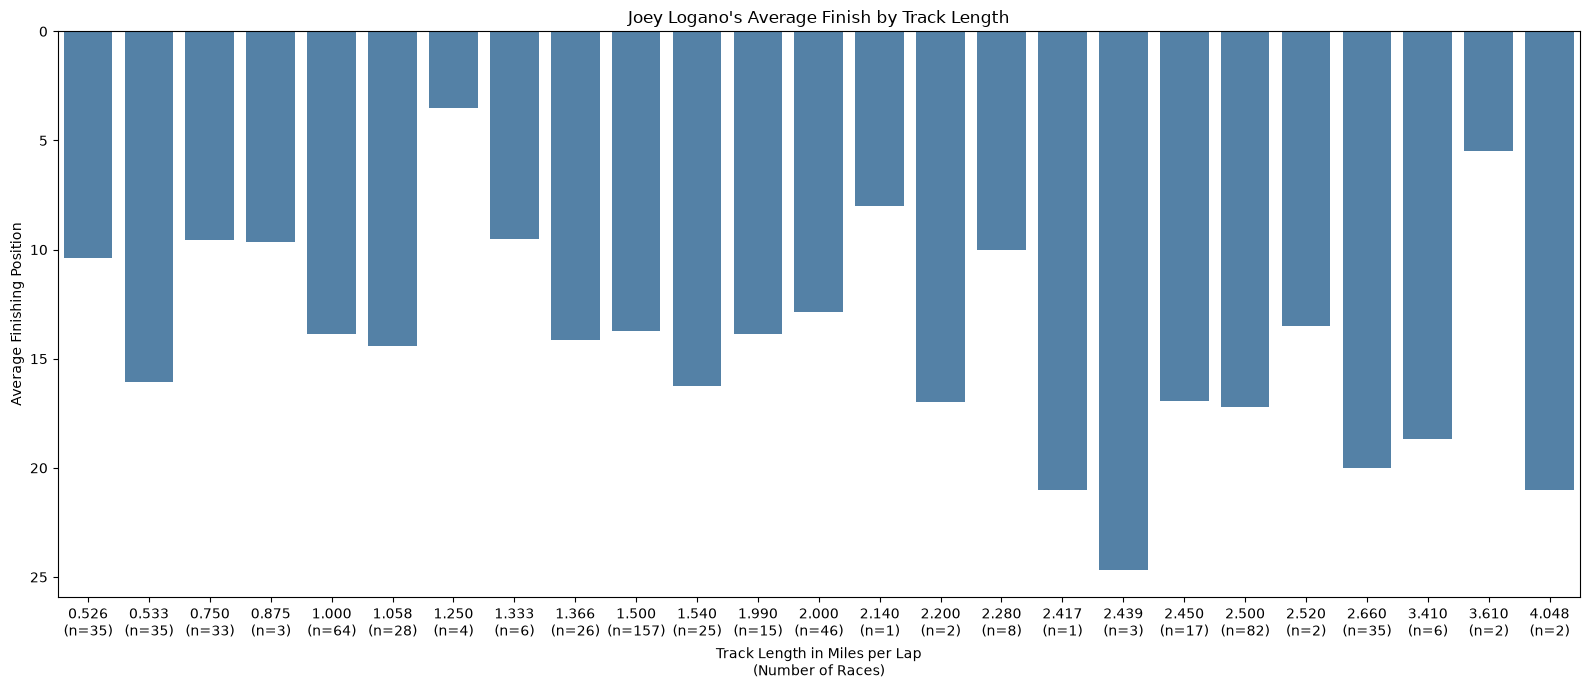

In [103]:
#visualize Logano's average finish by track length
plot_data = length_summary.sort_values("Length").copy()

plt.figure(figsize=(16, 7))

ax = sns.barplot(
    data=plot_data,
    x="Length",
    y="average_finish",
    color="steelblue"
)

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels([
    f"{length:.3f}\n(n={races})"
    for length, races in zip(
        plot_data["Length"],
        plot_data["races"]
    )
])

plt.gca().invert_yaxis()
plt.title("Joey Logano's Average Finish by Track Length")
plt.xlabel("Track Length in Miles per Lap\n(Number of Races)")
plt.ylabel("Average Finishing Position")
plt.tight_layout()
plt.show()

In [104]:
#compare results between even and odd years
logano["Year_Type"] = logano["Season"].apply(
    lambda year: "Even" if year % 2 == 0 else "Odd"
)

length_even_odd = (
    logano.groupby(["Length", "Year_Type"])
    .agg(
        races=("Finish", "size"),
        average_finish=("Finish", "mean")
    )
    .reset_index()
)

print(length_even_odd)

    Length Year_Type  races  average_finish
0    0.526      Even     17        6.882353
1    0.526       Odd     18       13.666667
2    0.533      Even     17       14.235294
3    0.533       Odd     18       17.777778
4    0.750      Even     16       10.312500
5    0.750       Odd     17        8.882353
6    0.875      Even      2       10.000000
7    0.875       Odd      1        9.000000
8    1.000      Even     31       11.612903
9    1.000       Odd     33       16.000000
10   1.058      Even     14       16.857143
11   1.058       Odd     14       11.928571
12   1.250      Even      2        3.000000
13   1.250       Odd      2        4.000000
14   1.333      Even      3        8.000000
15   1.333       Odd      3       11.000000
16   1.366      Even     14       13.000000
17   1.366       Odd     12       15.500000
18   1.500      Even     78       13.576923
19   1.500       Odd     79       13.886076
20   1.540      Even     12       16.250000
21   1.540       Odd     13     

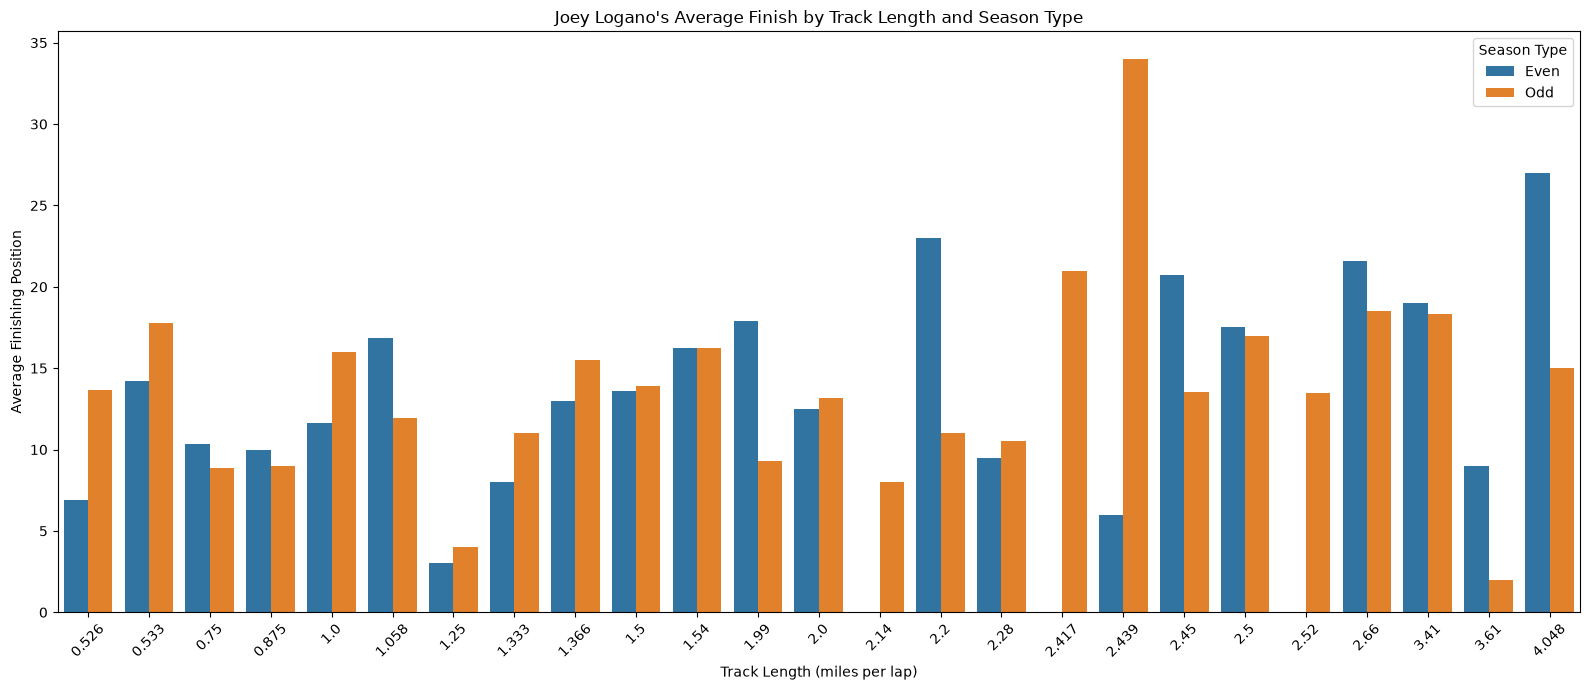

In [105]:
# visualize the difference in average finish in even and odd years by track length
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 7))

sns.barplot(
    data=length_even_odd,
    x="Length",
    y="average_finish",
    hue="Year_Type"
)

plt.title("Joey Logano's Average Finish by Track Length and Season Type")
plt.xlabel("Track Length (miles per lap)")
plt.ylabel("Average Finishing Position")
plt.xticks(rotation=45)
plt.legend(title="Season Type")
plt.tight_layout()
plt.show()

In [106]:
#quantify dnf status for Joey Logano
logano["DNF"] = (
    logano["Status"].str.strip().str.lower() != "running"
).astype(int)

In [107]:
print(logano["DNF"].value_counts())

DNF
0    582
1     60
Name: count, dtype: int64


In [108]:
#add total dnfs to the even and odd year comparison by track length
length_even_odd = (
    logano.groupby(["Length", "Year_Type"])
    .agg(
        races=("Finish", "size"),
        average_finish=("Finish", "mean"),
        wins=("Win", "sum"),
        average_rating=("Rating", "mean"),
        total_dnfs=("DNF", "sum"),
    )
    .reset_index()
)

print(length_even_odd)

    Length Year_Type  races  average_finish  wins  average_rating  total_dnfs
0    0.526      Even     17        6.882353   1.0      104.605882           0
1    0.526       Odd     18       13.666667   0.0       90.766667           0
2    0.533      Even     17       14.235294   1.0       94.011765           1
3    0.533       Odd     18       17.777778   2.0       79.661111           3
4    0.750      Even     16       10.312500   2.0      100.400000           0
5    0.750       Odd     17        8.882353   1.0       93.558824           1
6    0.875      Even      2       10.000000   0.0       99.450000           0
7    0.875       Odd      1        9.000000   0.0       77.200000           0
8    1.000      Even     31       11.612903   4.0       97.680645           4
9    1.000       Odd     33       16.000000   0.0       83.218182           4
10   1.058      Even     14       16.857143   1.0       85.478571           2
11   1.058       Odd     14       11.928571   1.0       87.95000

In [109]:
#check what happened to Logano on 1.5 mile tracks where he did not finish as they were tied at 6 dnfs each in even and odd years
logano[
    (logano["Length"] == 1.5) &
    (logano["DNF"] == 1)
][["Season", "Race", "Track", "Status", "Year_Type"]].sort_values(
    ["Year_Type", "Season", "Race"]
)

,Season,Race,Track,Status,Year_Type
78601,2010,36,Homestead-Miami Speedway,accident,Even
86778,2016,11,Kansas Speedway,accident,Even
87059,2016,18,Kentucky Speedway,accident,Even
92716,2020,19,Kansas Speedway,accident,Even
95271,2022,14,Charlotte Motor Speedway,accident,Even
100551,2026,11,Texas Motor Speedway,accident,Even
80061,2011,34,Texas Motor Speedway,engine,Odd
82041,2013,8,Kansas Speedway,accident,Odd
82856,2013,27,Chicagoland Speedway,engine,Odd
88208,2017,11,Kansas Speedway,accident,Odd


In [110]:
# find out what the DNF statuses were for Joey Logano on 1.5 mile tracks in even and odd years
pd.crosstab(
    logano.loc[
        (logano["Length"] == 1.5) &
        (logano["DNF"] == 1),
        "Year_Type"
    ],
    logano.loc[
        (logano["Length"] == 1.5) &
        (logano["DNF"] == 1),
        "Status"
    ]
)

Status,DVP,accident,engine
Year_Type,,,
Even,0,6,0
Odd,1,2,3


In [111]:
# add a variable to calculate the position gain or loss from pole position to finishing position for Joey Logano
logano["Position_Gain"] = logano["Start"] - logano["Finish"]

even_odd_summary = (
    logano.groupby("Year_Type")
    .agg(
        races=("Finish", "size"),
        average_finish=("Finish", "mean"),
        wins=("Win", "sum"),
        win_rate=("Win", "mean"),
        average_rating=("Rating", "mean"),
        average_position_gain=("Position_Gain", "mean"),
        total_dnfs=("DNF", "sum"),
        dnf_rate=("DNF", "mean")
    )
    .reset_index()
)

even_odd_summary["win_rate"] = even_odd_summary["win_rate"] * 100
even_odd_summary["dnf_rate"] = even_odd_summary["dnf_rate"] * 100

print(even_odd_summary.round(2))

  Year_Type  races  average_finish  wins  win_rate  average_rating  \
0      Even    318           14.14  25.0      7.86           91.48   
1       Odd    324           14.58  14.0      4.32           87.66   

   average_position_gain  total_dnfs  dnf_rate  
0                  -2.97          34     10.69  
1                  -1.86          26      8.02  


In [112]:
# find if any of the continuous variables have a significant difference between even and odd years using a t-test
from scipy.stats import ttest_ind, chi2_contingency
import pandas as pd

even = logano[logano["Year_Type"] == "Even"]
odd = logano[logano["Year_Type"] == "Odd"]

# Continuous variables
continuous_variables = [
    "Finish",
    "Rating",
    "Position_Gain"
]

for variable in continuous_variables:
    even_values = even[variable].dropna()
    odd_values = odd[variable].dropna()

    test_statistic, p_value = ttest_ind(
        even_values,
        odd_values,
        equal_var=False
    )

    print(f"{variable}")
    print(f"Even mean: {even_values.mean():.2f}")
    print(f"Odd mean: {odd_values.mean():.2f}")
    print(f"p-value: {p_value:.4f}")
    print()

# Binary variables
binary_variables = [
    "Win",
    "DNF"
]

for variable in binary_variables:
    table = pd.crosstab(logano["Year_Type"], logano[variable])

    chi2, p_value, degrees_of_freedom, expected = chi2_contingency(table)

    print(f"{variable}")
    print(f"p-value: {p_value:.4f}")
    print()

Finish
Even mean: 14.14
Odd mean: 14.58
p-value: 0.6176

Rating
Even mean: 91.48
Odd mean: 87.66
p-value: 0.0394

Position_Gain
Even mean: -2.97
Odd mean: -1.86
p-value: 0.2707

Win
p-value: 0.0868

DNF
p-value: 0.3053



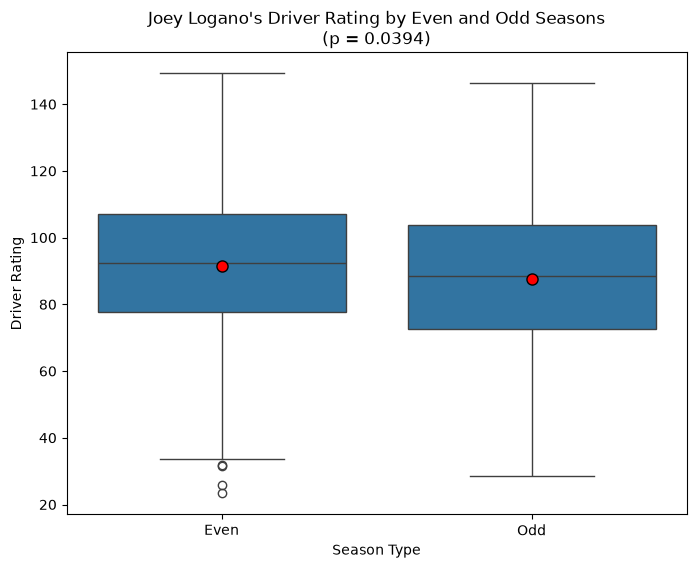

In [113]:
# visualize the difference in driver rating between even and odd years using a boxplot as it is the only significant continuous variable from the t-test
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=logano,
    x="Year_Type",
    y="Rating",
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markersize": 8
    }
)

plt.title("Joey Logano's Driver Rating by Even and Odd Seasons\n(p = 0.0394)")
plt.xlabel("Season Type")
plt.ylabel("Driver Rating")
plt.show()

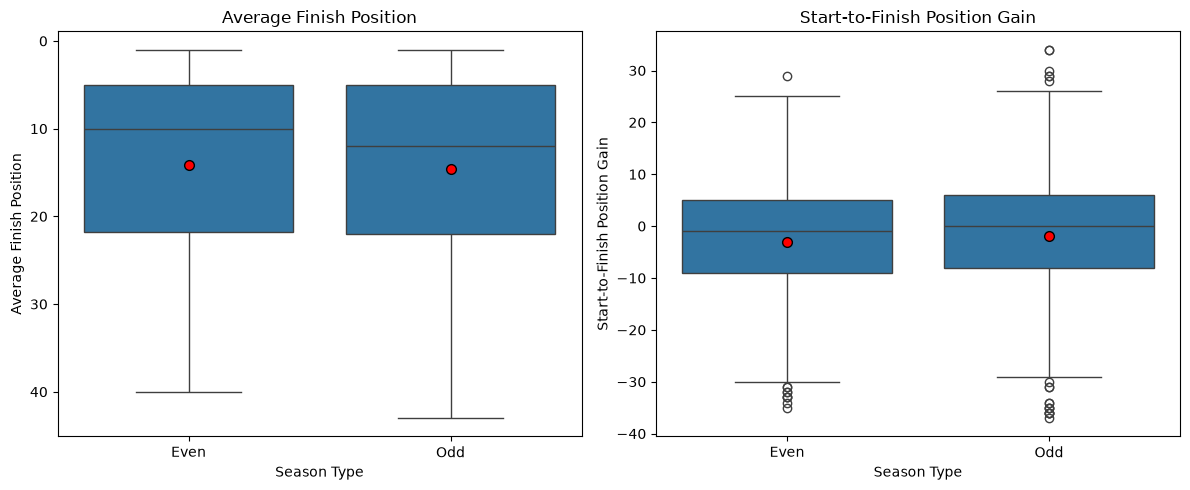

In [114]:
# look at visualizations for the other continuous variables that were not significant in the t-test to see if there were still any interesting patterns or trends
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

variables = [
    ("Finish", "Average Finish Position"),
    ("Position_Gain", "Start-to-Finish Position Gain")
]

for ax, (variable, label) in zip(axes, variables):
    sns.boxplot(
        data=logano,
        x="Year_Type",
        y=variable,
        ax=ax,
        showmeans=True,
        meanprops={
            "marker": "o",
            "markerfacecolor": "red",
            "markeredgecolor": "black",
            "markersize": 7
        }
    )

    ax.set_title(label)
    ax.set_xlabel("Season Type")
    ax.set_ylabel(label)

# Lower finishing position is better
axes[0].invert_yaxis()

plt.tight_layout()
plt.show()

In [115]:
# create a comparison dataframe for multiple drivers to see if there are any patterns or trends in their performance between even and odd years
drivers = [
    "Joey Logano",
    "Ryan Blaney",
    "Denny Hamlin",
    "Kyle Larson",
    "Kyle Busch"
]

comparison = cup[
    cup["Driver"].isin(drivers)
].copy()

comparison["Year_Type"] = comparison["Season"].apply(
    lambda year: "Even" if year % 2 == 0 else "Odd"
)

comparison["Position_Gain"] = (
    comparison["Start"] - comparison["Finish"]
)

comparison["DNF"] = (
    comparison["Status"].str.strip().str.lower() != "running"
).astype(int)

In [116]:
# create a table to compare the performance of the selected drivers in even and odd years
driver_even_odd_summary = (
    comparison.groupby(["Driver", "Year_Type"])
    .agg(
        races=("Finish", "size"),
        average_finish=("Finish", "mean"),
        wins=("Win", "sum"),
        win_rate=("Win", "mean"),
        average_rating=("Rating", "mean"),
        average_position_gain=("Position_Gain", "mean"),
        total_dnfs=("DNF", "sum"),
        dnf_rate=("DNF", "mean")
    )
    .reset_index()
)

driver_even_odd_summary["win_rate"] *= 100
driver_even_odd_summary["dnf_rate"] *= 100

print(driver_even_odd_summary.round(2))

         Driver Year_Type  races  average_finish  wins  win_rate  \
0  Denny Hamlin      Even    386           12.78  36.0      9.33   
1  Denny Hamlin       Odd    362           13.35  28.0      7.73   
2   Joey Logano      Even    318           14.14  25.0      7.86   
3   Joey Logano       Odd    324           14.58  14.0      4.32   
4    Kyle Busch      Even    378           14.69  28.0      7.41   
5    Kyle Busch       Odd    384           14.01  35.0      9.11   
6   Kyle Larson      Even    210           14.04  10.0      4.76   
7   Kyle Larson       Odd    219           14.35  22.0     10.05   
8   Ryan Blaney      Even    209           14.77   8.0      3.83   
9   Ryan Blaney       Odd    196           15.21  12.0      6.12   

   average_rating  average_position_gain  total_dnfs  dnf_rate  
0           94.85                  -0.60          30      7.77  
1           95.42                  -1.84          30      8.29  
2           91.48                  -2.97          34    

In [117]:
# find if any of the other drivers have anything of significance in the continuous variables other than the single Logano variable that was significant in the t-test
import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency

drivers = [
    "Joey Logano",
    "Ryan Blaney",
    "Denny Hamlin",
    "Kyle Larson",
    "Kyle Busch"
]

continuous_variables = [
    "Finish",
    "Rating",
    "Position_Gain"
]

binary_variables = [
    "Win",
    "DNF"
]

results = []

for driver in drivers:
    driver_data = comparison[
        comparison["Driver"] == driver
    ]

    even = driver_data[
        driver_data["Year_Type"] == "Even"
    ]

    odd = driver_data[
        driver_data["Year_Type"] == "Odd"
    ]

    # Welch's t-tests for continuous variables
    for variable in continuous_variables:
        even_values = even[variable].dropna()
        odd_values = odd[variable].dropna()

        test_statistic, p_value = ttest_ind(
            even_values,
            odd_values,
            equal_var=False
        )

        results.append({
            "Driver": driver,
            "Variable": variable,
            "Even_Value": even_values.mean(),
            "Odd_Value": odd_values.mean(),
            "Difference_Even_Minus_Odd": (
                even_values.mean() - odd_values.mean()
            ),
            "P_Value": p_value,
            "Significant": "Yes" if p_value < 0.05 else "No"
        })

    # Chi-square tests for binary variables
    for variable in binary_variables:
        table = pd.crosstab(
            driver_data["Year_Type"],
            driver_data[variable]
        )

        table = table.reindex(
            index=["Even", "Odd"],
            columns=[0, 1],
            fill_value=0
        )

        chi2, p_value, degrees_of_freedom, expected = (
            chi2_contingency(table)
        )

        even_rate = even[variable].mean() * 100
        odd_rate = odd[variable].mean() * 100

        results.append({
            "Driver": driver,
            "Variable": variable + " Rate (%)",
            "Even_Value": even_rate,
            "Odd_Value": odd_rate,
            "Difference_Even_Minus_Odd": (
                even_rate - odd_rate
            ),
            "P_Value": p_value,
            "Significant": "Yes" if p_value < 0.05 else "No"
        })

results_table = pd.DataFrame(results)

print(
    results_table.round({
        "Even_Value": 2,
        "Odd_Value": 2,
        "Difference_Even_Minus_Odd": 2,
        "P_Value": 4
    })
)

          Driver       Variable  Even_Value  Odd_Value  \
0    Joey Logano         Finish       14.14      14.58   
1    Joey Logano         Rating       91.48      87.66   
2    Joey Logano  Position_Gain       -2.97      -1.86   
3    Joey Logano   Win Rate (%)        7.86       4.32   
4    Joey Logano   DNF Rate (%)       10.69       8.02   
5    Ryan Blaney         Finish       14.77      15.21   
6    Ryan Blaney         Rating       91.10      89.26   
7    Ryan Blaney  Position_Gain       -3.22      -3.18   
8    Ryan Blaney   Win Rate (%)        3.83       6.12   
9    Ryan Blaney   DNF Rate (%)       11.96      14.29   
10  Denny Hamlin         Finish       12.78      13.35   
11  Denny Hamlin         Rating       94.85      95.42   
12  Denny Hamlin  Position_Gain       -0.60      -1.84   
13  Denny Hamlin   Win Rate (%)        9.33       7.73   
14  Denny Hamlin   DNF Rate (%)        7.77       8.29   
15   Kyle Larson         Finish       14.04      14.35   
16   Kyle Lars